# 0. 세팅하기

## 0. 설치하기

In [1]:
!pip install duckdb

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.8 MB/s eta 0:00:0000:0100:01


In [16]:
!pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable


## 1. 세팅하기

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [30]:
import duckdb as dd
import dotenv
import os
import pandas as pd

In [80]:
# 한글 폰트 지정
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 경로 확인 필요
fontprop = fm.FontProperties(fname=font_path)

plt.rc('font', family=fontprop.get_name())

In [34]:
# 컬럼 모두 출력
pd.set_option('display.max_columns', None)

In [20]:
# .env 파일 경로 찾기

env_path = dotenv.find_dotenv()

In [21]:
# .env 파일 불러오기  (내용이 있으면 -> True, 없으면 -> False)

dotenv.load_dotenv(
    dotenv_path=env_path,
    override=True
)

True

In [5]:
mem_con = dd.connect("mydb.duckdb")

In [26]:
HMAC_ID = os.getenv("HMAC_ID")
HMAC_PW = os.getenv("HMAC_PW")

secret_gcs = f"""
CREATE SECRET (
    TYPE GCS,
    KEY_ID '{HMAC_ID}',
    SECRET '{HMAC_PW}'
);
"""

mem_con.execute(secret_gcs)

In [27]:
mem_con.execute("FROM duckdb_secrets()").df()

,name,type,provider,persistent,storage,scope,secret_string
0,__default_gcs,gcs,config,False,memory,"[gcs://, gs://]",name=__default_gcs;type=gcs;provider=config;se...


## 2. 파일 불러오기

### 1) 기존데이블

In [306]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userquestionrecord.parquet')
"""

userquestionrecord_df = mem_con.execute(_query).df()

In [31]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_attendance.parquet')
"""

attendance_df = mem_con.execute(_query).df()

In [298]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_pointhistory.parquet')
"""

pointhistory_df = mem_con.execute(_query).df()

In [33]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionpiece.parquet')
"""

polls_questionpiece_df = mem_con.execute(_query).df()

In [34]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionset.parquet')
"""

polls_questionset_df = mem_con.execute(_query).df()

In [71]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_question.parquet')
"""

polls_question_df = mem_con.execute(_query).df()

### 2) 병합테이블

In [218]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet')
"""

paymenthistory_df = mem_con.execute(_query).df()

In [28]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet')
"""

question_df = mem_con.execute(_query).df()

In [30]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/vote_point_df.parquet')
"""

vote_point_df = mem_con.execute(_query).df()

In [31]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_info_df.parquet')
"""

event_info_df = mem_con.execute(_query).df()

In [32]:
_query = """
FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/user_df.parquet')
"""

user_df = mem_con.execute(_query).df()

### 3) duckdb에 저장

In [127]:
mem_con.execute("""
                CREATE TABLE user_df AS
                SELECT * FROM user_df
                """)

In [130]:
mem_con.execute("""
                CREATE TABLE vote_point_df AS
                SELECT * FROM vote_point_df
                """)

In [131]:
tables = mem_con.execute("SHOW TABLES").fetchall()
print(tables)

[('user_df',), ('vote_point_df',)]


# 2. 피쳐엔지니어링

### 2) 질문테이블 : 질문piece, 질문set, 질문 테이블 병합

questionset 1정규화

In [132]:
polls_questionset_df.head()

,id,question_piece_id_list,opening_time,status,created_at,user_id
0,99817,"[998458, 998459, 998460, 998461, 998462, 99846...",2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99830,"[998588, 998589, 998590, 998591, 998592, 99859...",2023-04-28 12:28:07,F,2023-04-28 12:28:07,849438
2,99840,"[998689, 998691, 998693, 998695, 998697, 99869...",2023-04-28 12:28:38,F,2023-04-28 12:28:38,847375
3,99841,"[998688, 998690, 998692, 998694, 998696, 99869...",2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446
4,99848,"[998768, 998769, 998770, 998771, 998772, 99877...",2023-04-28 12:28:57,F,2023-04-28 12:28:57,849477


In [133]:
print("shape : ", polls_questionpiece_df.shape)
print("id 갯수 : ", polls_questionpiece_df['id'].nunique())

shape :  (1265476, 5)


id 갯수 :  1265476


In [134]:
# 정규화 대상 DataFrame
df = polls_questionset_df.copy()

# 리스트 컬럼 정규화 (explode 사용)
df['question_piece_id_list'] = df['question_piece_id_list'].apply(eval)  # 문자열로 저장된 리스트를 진짜 리스트로 변환
normalized_df = df.explode('question_piece_id_list')[['id', 'question_piece_id_list']]

# 열 이름 바꾸기 (선택사항)
normalized_df = normalized_df.rename(columns={'question_piece_id_list': 'question_piece_id'})

# 결과 확인
normalized_df.head()

,id,question_piece_id
0,99817,998458
0,99817,998459
0,99817,998460
0,99817,998461
0,99817,998462


In [135]:
merged_df = normalized_df.merge(
    df[['id', 'opening_time', 'status', 'created_at', 'user_id']],
    how='left',
    on='id'
)

In [136]:
# 정규화 완료 테이블
merged_df.head()

,id,question_piece_id,opening_time,status,created_at,user_id
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436


In [137]:
# question_piece_id 중복값 확인
merged_df['question_piece_id'].duplicated().sum()

0

In [138]:
merged_df['question_piece_id'].nunique()

1583840

questionpiece 테이블 합치기

In [139]:
polls_questionpiece_df.head()

,id,is_voted,created_at,question_id,is_skipped
0,998458,1,2023-04-28 12:27:22,252,0
1,998459,1,2023-04-28 12:27:22,244,0
2,998460,1,2023-04-28 12:27:22,183,0
3,998461,1,2023-04-28 12:27:22,101,0
4,998462,1,2023-04-28 12:27:22,209,0


In [140]:
merged_df.head()

,id,question_piece_id,opening_time,status,created_at,user_id
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436


In [141]:
question_df = merged_df.merge(
    polls_questionpiece_df, 
    how='left', 
    left_on='question_piece_id', 
    right_on='id',
    suffixes=('_set','_piece'))

In [142]:
question_df.head(20)

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0
5,99817,998463,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998463.0,1.0,2023-04-28 12:27:22,239.0,0.0
6,99817,998464,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998464.0,1.0,2023-04-28 12:27:22,146.0,0.0
7,99817,998465,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998465.0,1.0,2023-04-28 12:27:22,297.0,0.0
8,99817,998466,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998466.0,1.0,2023-04-28 12:27:22,294.0,0.0
9,99817,998467,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998467.0,1.0,2023-04-28 12:27:22,201.0,0.0


In [143]:
question_df.isna().sum()

id_set                    0
question_piece_id         0
opening_time              0
status                    0
created_at_set            0
user_id                   0
id_piece             318364
is_voted             318364
created_at_piece     318364
question_id          318364
is_skipped           318364
dtype: int64

In [144]:
nan_rows = question_df[question_df.isna().any(axis=1)]
nan_rows

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped
18,99830,998596,2023-04-28 12:28:07,F,2023-04-28 12:28:07,849438,NaN,NaN,NaT,NaN,NaN
30,99841,998688,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
31,99841,998690,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
32,99841,998692,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
35,99841,998698,2023-04-28 12:28:38,F,2023-04-28 12:28:38,849446,NaN,NaN,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1583694,20835070,208351465,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583695,20835070,208351466,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583696,20835070,208351467,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN
1583698,20835070,208351469,2024-03-19 12:53:58,F,2024-03-19 12:53:58,1583358,NaN,NaN,NaT,NaN,NaN


In [145]:
nan_rows['status'].value_counts()

status
F    318351
O        11
C         2
Name: count, dtype: int64

polls_question_df랑 merge

In [146]:
polls_question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [147]:
question_df2 = question_df.merge(
  polls_question_df,
  how='left',
  left_on='question_id',
  right_on='id'
)

In [148]:
question_df2.head()

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped,id,question_text,created_at
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0,244.0,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0,183.0,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-01 11:09:14
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0,101.0,미래의 틱톡커는?,2023-03-31 15:22:54
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0,209.0,항상 좋은 냄새가 나는 사람은?,2023-04-01 11:09:20


null 제거

In [149]:
question_df2.isna().sum()

id_set                    0
question_piece_id         0
opening_time              0
status                    0
created_at_set            0
user_id                   0
id_piece             318364
is_voted             318364
created_at_piece     318364
question_id          318364
is_skipped           318364
id                   318364
question_text        318364
created_at           318364
dtype: int64

In [150]:
question_df_notnull = question_df2.dropna()
question_df_notnull

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,id_piece,is_voted,created_at_piece,question_id,is_skipped,id,question_text,created_at
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998458.0,1.0,2023-04-28 12:27:22,252.0,0.0,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998459.0,1.0,2023-04-28 12:27:22,244.0,0.0,244.0,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998460.0,1.0,2023-04-28 12:27:22,183.0,0.0,183.0,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-01 11:09:14
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998461.0,1.0,2023-04-28 12:27:22,101.0,0.0,101.0,미래의 틱톡커는?,2023-03-31 15:22:54
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,998462.0,1.0,2023-04-28 12:27:22,209.0,0.0,209.0,항상 좋은 냄새가 나는 사람은?,2023-04-01 11:09:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1583835,20838446,208385226,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385226.0,0.0,2024-05-07 11:32:30,960.0,0.0,960.0,가장 인싸일 것 같은 친구는?,2023-05-15 14:00:19
1583836,20838446,208385227,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385227.0,0.0,2024-05-07 11:32:30,1402.0,0.0,1402.0,가장 리더쉽 있을 것 같은 사람,2023-05-15 14:03:19
1583837,20838446,208385228,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385228.0,0.0,2024-05-07 11:32:30,1676.0,0.0,1676.0,화장 전후 가장 비슷할 것 같은 사람은?,2023-06-02 08:06:24
1583838,20838446,208385229,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,208385229.0,0.0,2024-05-07 11:32:30,3115.0,0.0,3115.0,가장 박새로이컷이 잘 어울릴 것 같은 사람,2023-06-02 08:07:08


In [151]:
question_df_notnull.shape

(1265476, 14)

columns 정리

In [152]:
question_df_notnull.columns

Index(['id_set', 'question_piece_id', 'opening_time', 'status',
       'created_at_set', 'user_id', 'id_piece', 'is_voted', 'created_at_piece',
       'question_id', 'is_skipped', 'id', 'question_text', 'created_at'],
      dtype='object')

In [153]:
final_question_df = question_df_notnull[['id_set', 'question_piece_id', 'opening_time', 'status',
                                          'created_at_set', 'user_id', 'is_voted', 'is_skipped', 'created_at_piece',
                                          'question_id',  'question_text']]

In [154]:
final_question_df

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,is_voted,is_skipped,created_at_piece,question_id,question_text
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?
1,99817,998459,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,244.0,대학교에서 학생회장할 것 같은 사람은?
2,99817,998460,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,183.0,나의 자존감을 가장 많이 높여줬던 사람은?
3,99817,998461,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,101.0,미래의 틱톡커는?
4,99817,998462,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,209.0,항상 좋은 냄새가 나는 사람은?
...,...,...,...,...,...,...,...,...,...,...,...
1583835,20838446,208385226,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,960.0,가장 인싸일 것 같은 친구는?
1583836,20838446,208385227,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1402.0,가장 리더쉽 있을 것 같은 사람
1583837,20838446,208385228,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,1676.0,화장 전후 가장 비슷할 것 같은 사람은?
1583838,20838446,208385229,2024-05-07 12:12:30,C,2024-05-07 11:32:30,945560,0.0,0.0,2024-05-07 11:32:30,3115.0,가장 박새로이컷이 잘 어울릴 것 같은 사람


추출하기

In [155]:
# mem_con.execute("""
#                COPY final_question_df TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet' (FORMAT PARQUET);
#                """)

# 3. EDA

### 1) 회원분포 확인

In [156]:
user_df.head()

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1...",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN,NaN,None,NaN,NaN,NaN,None,NaN,None
1,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None
2,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1.0,219728.0,"[""2023-05-29""]",1.0,1.0,1.0,None,NaN,None
3,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21,1.0,315353.0,"[""2023-06-05"", ""2023-06-06""]",1.0,1.0,1.0,None,NaN,None
4,832520,0,0,M,1039,"[874050, 849763, 874212, 844297, 838541, 84004...",0,2023-03-29 12:56:35.049311,[],[],N,0,29,0,15,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None


In [157]:
# 학교/학년별 유저수
school_grade_df = user_df.groupby('school_type')['grade'].value_counts().reset_index()

# 소계 만들기
subtotals = (
    school_grade_df.groupby('school_type')['count']
    .sum()
    .reset_index()
    .assign(grade='소계')
)

# 총계 만들기
grand_total = pd.DataFrame({
    'school_type': ['총계'],
    'grade': ['총계'],
    'count': [school_grade_df['count'].sum()]
})

# 합치기
final_df = pd.concat([school_grade_df, subtotals, grand_total], ignore_index=True)

# 총합 가져오기
total_count = final_df.loc[(final_df['school_type'] == '총계') & (final_df['grade'] == '총계'), 'count'].values[0]

# percentage 컬럼 추가
final_df['percentage(%)'] = round((final_df['count'] / total_count) * 100, 2)

final_df


,school_type,grade,count,percentage(%)
0,H,1.0,200783,29.66
1,H,2.0,126660,18.71
2,H,3.0,48946,7.23
3,M,2.0,153745,22.71
4,M,3.0,146729,21.67
5,M,1.0,124,0.02
6,H,소계,376389,55.60
7,M,소계,300598,44.40
8,총계,총계,676987,100.00


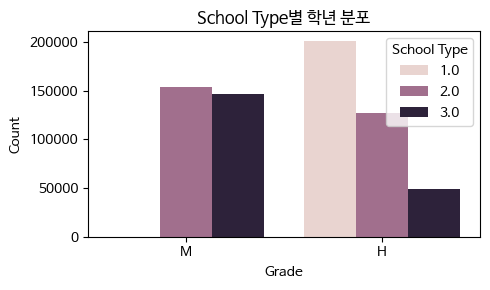

In [158]:
plot_df = final_df[
    (final_df['grade'] != '소계') & 
    (final_df['school_type'] != '총계')
]

plt.figure(figsize=(5,3))
sns.barplot(data=plot_df, x='school_type', y='count', hue='grade', order=['M', 'H'])

plt.title('School Type별 학년 분포')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.legend(title='School Type')
plt.tight_layout()
plt.show()

In [277]:
user_df.groupby('school_type')['school_id'].nunique()

school_type
H    2457
M    3093
Name: school_id, dtype: int64

### 1-2) 회원 포인트 보유현황

(이상치 제거) point 4857.5 미만의 값만 추출

In [ ]:
# point 상한값 설정
q1 = user_df['point'].quantile(0.25)
q3 = user_df['point'].quantile(0.75)

iqr = q3 - q1 

print(q3 + 1.5*iqr)

4857.5


In [203]:
user_simple_table = mem_con.execute("""
                            SELECT user_id,	is_superuser,	is_staff,	gender,	point, grade, school_type
                            FROM user_df
                            WHERE point < 4857.5
                            """).df()
user_simple_table.head()

,user_id,is_superuser,is_staff,gender,point,grade,school_type
0,831956,1,1,None,600,NaN,None
1,831962,0,0,F,2248,2.0,None
2,832151,0,0,M,1519,1.0,None
3,832340,0,0,F,57,1.0,None
4,832520,0,0,M,1039,2.0,None


In [210]:
print("point 상한선 제한 전 : ", user_df.shape)
print("point 상한선 제한 후 : ", user_simple_table.shape)
print("차이 : ", user_df.shape[0] - user_simple_table.shape[0], "(", round((user_df.shape[0] - user_simple_table.shape[0])/user_df.shape[0]*100,2) ,"%)")

point 상한선 제한 전 :  (677085, 24)
point 상한선 제한 후 :  (634476, 7)
차이 :  42609 ( 6.29 %)


In [212]:
user_simple_table.sort_values(by='point', ascending=False)

,user_id,is_superuser,is_staff,gender,point,grade,school_type
91439,950740,0,0,F,4857,2.0,M
387301,1295984,0,0,F,4857,1.0,H
283411,1173728,0,0,F,4857,2.0,M
290521,1182101,0,0,F,4857,1.0,H
251397,1136516,0,0,F,4857,2.0,M
...,...,...,...,...,...,...,...
93716,953367,0,0,M,0,3.0,M
506649,1437209,0,0,M,0,2.0,H
263751,1150967,0,0,M,0,1.0,H
151391,1020318,0,0,M,0,2.0,M


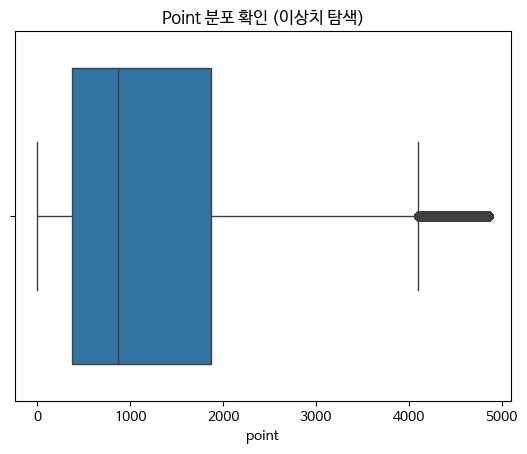

In [213]:
sns.boxplot(x=user_simple_table['point'])
plt.title('Point 분포 확인 (이상치 탐색)')
plt.show()

포인트 구매이력과 비교

In [214]:
positive_point_users = user_simple_table[user_simple_table['point'] > 0]
zero_point_users = user_simple_table[user_simple_table['point'] == 0]
print("포인트가 있는 유저 수:", len(positive_point_users))
print("포인트가 0인 유저 수:", len(zero_point_users))

포인트가 있는 유저 수: 634278
포인트가 0인 유저 수: 198


In [219]:
paymenthistory_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


In [220]:
paymenthistory_df['user_id'].nunique()

59192

학교_학년별 비교

In [281]:
user_df['school_grade'] = user_df['school_type'] + '_' + user_df['grade'].astype('str')

In [284]:
user_school = user_df[['user_id', 'school_grade']]
user_school

,user_id,school_grade
0,831956,NaN
1,831962,NaN
2,832151,NaN
3,832340,NaN
4,832520,NaN
...,...,...
677080,1583729,H_3.0
677081,1583730,M_3.0
677082,1583731,H_3.0
677083,1583732,H_3.0


In [288]:
merged_df = vote_point_df[['user_id', 'question_id', 'delta_point', 'created_at']].merge(user_school, how='left', on='user_id')
merged_df

,user_id,question_id,delta_point,created_at,school_grade
0,849452,209,-300.0,2023-04-28 12:30:48,H_2.0
1,849477,253,-300.0,2023-04-28 12:34:17,H_2.0
2,849566,117,-300.0,2023-04-28 12:41:45,H_2.0
3,849558,110,-300.0,2023-04-28 12:46:14,H_2.0
4,850039,210,-300.0,2023-04-28 13:18:14,H_2.0
...,...,...,...,...,...
1217549,1001607,2614,16.0,2024-05-07 11:29:07,H_1.0
1217550,855525,1679,10.0,2024-05-08 01:34:56,H_1.0
1217551,855525,2605,28.0,2024-05-08 01:35:02,H_1.0
1217552,855525,3801,22.0,2024-05-08 01:36:00,H_1.0


In [296]:
merged_df.groupby('school_grade')['delta_point'].agg(['count', 'mean'])

,count,mean
school_grade,,
H_1.0,442785,6.368983
H_2.0,357309,5.747893
H_3.0,156616,6.165513
M_2.0,157174,9.605628
M_3.0,103670,7.284460


### 1-3) 친구 수 & 출석일 반영 후 상관관계 분석

In [244]:
user_df['friend_count'] = user_df['friend_id_list'].apply(len)

In [248]:
user_df['attendance_count'] = user_df['attendance_date_list'].apply(
  lambda x: len(x) if isinstance(x, list) else 0
  )

In [253]:
import ast

def safe_len(x):
    if isinstance(x, str):
        try:
            return len(ast.literal_eval(x))
        except:
            return 0
    elif isinstance(x, list):
        return len(x)
    return 0

user_df['attendance_count'] = user_df['attendance_date_list'].apply(safe_len)

In [254]:
user_df.head()

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,friend_count,attendance_count
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1...",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN,NaN,None,NaN,NaN,NaN,None,NaN,None,53,0
1,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None,357,0
2,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1.0,219728.0,"[""2023-05-29""]",1.0,1.0,1.0,None,NaN,None,427,1
3,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21,1.0,315353.0,"[""2023-06-05"", ""2023-06-06""]",1.0,1.0,1.0,None,NaN,None,471,2
4,832520,0,0,M,1039,"[874050, 849763, 874212, 844297, 838541, 84004...",0,2023-03-29 12:56:35.049311,[],[],N,0,29,0,15,12.0,NaN,None,2.0,1.0,1.0,None,NaN,None,151,0


In [257]:
user_df[['friend_count','attendance_count']].describe()

,friend_count,attendance_count
count,677085.000000,677085.000000
mean,466.653083,3.282198
std,281.576664,7.307679
min,2.000000,0.000000
25%,272.000000,0.000000
50%,423.000000,0.000000
75%,612.000000,4.000000
max,12268.000000,310.000000


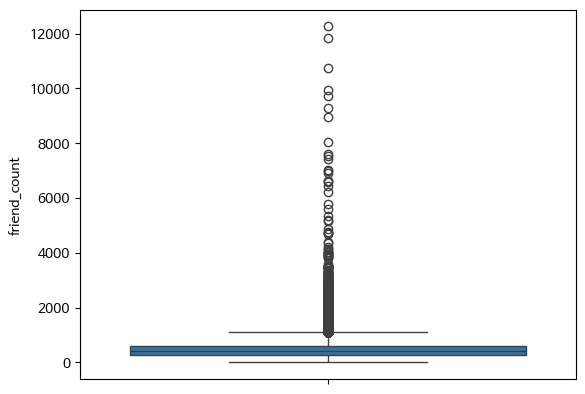

In [259]:
sns.boxplot(user_df['friend_count'])
plt.show()

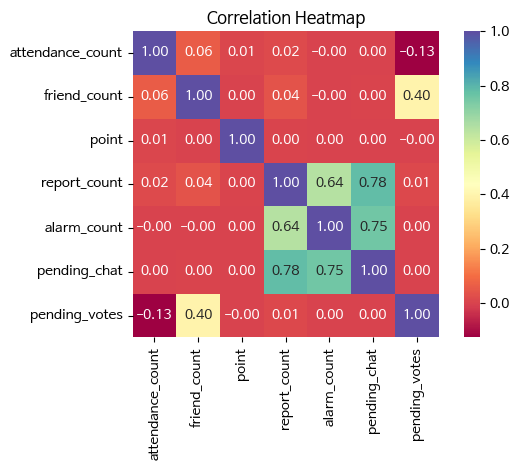

In [264]:
correlation = user_df[['attendance_count', 'friend_count', 'point', 'report_count',	'alarm_count',	'pending_chat',	'pending_votes']].corr()

sns.heatmap(correlation, annot=True, cmap='Spectral', fmt=".2f", square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [265]:
user_df['ban_status'].value_counts()

ban_status
N     668432
W       7855
NB       608
RB       190
Name: count, dtype: int64

### 2) 투표 참여 유저 비율 확인

In [159]:
user_cnt = user_df['user_id'].nunique()
chosen_user_cnt = vote_point_df['chosen_user_id'].nunique()
vote_user_cnt = vote_point_df['user_id'].nunique()

In [160]:
print("전체 유저수 : ", user_cnt)
print("선택된 유저수 : ", chosen_user_cnt, "(", round(chosen_user_cnt/user_cnt*100,3) , "%)")
print("선택한 유저수 : ", vote_user_cnt, "(", round(vote_user_cnt/user_cnt*100, 3), "%)")

전체 유저수 :  677085
선택된 유저수 :  15426 ( 2.278 %)
선택한 유저수 :  4849 ( 0.716 %)


In [161]:
user_df['user_id'].nunique()

677085

In [162]:
vote_point_df.head()

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,created_at_point,user_question_record_id,id_point,delta_point,user_id_point,time_diff
0,772123,I,2023-04-28 12:30:48,849489,209,849452,999059,0,N,2023-04-28 12:30:48,0,1,2023-04-28 17:28:06,772123.0,829075.0,-300.0,849489.0,17838.0
1,772628,I,2023-04-28 12:34:17,849436,253,849477,998774,0,N,2023-04-28 12:34:17,0,1,2023-04-29 02:27:33,772628.0,849680.0,-300.0,849436.0,49996.0
2,773997,I,2023-04-28 12:41:45,849479,117,849566,999684,0,N,2023-04-28 12:41:45,0,1,2023-04-28 14:31:21,773997.0,808783.0,-300.0,849479.0,6576.0
3,774559,I,2023-04-28 12:46:14,849503,110,849558,1003854,1,N,2023-04-28 12:46:14,0,1,2023-04-29 10:25:00,774559.0,926292.0,-300.0,849503.0,77926.0
4,778695,I,2023-04-28 13:18:14,849983,210,850039,1010379,0,N,2023-04-28 13:18:14,0,1,2023-04-28 15:41:47,778695.0,819109.0,-300.0,849983.0,8613.0


In [163]:
chosen_set = set(vote_point_df['chosen_user_id'].dropna().astype(int))
user_set = set(vote_point_df['user_id'].dropna().astype(int))

In [164]:
# 2. 겹치는 사람 수
intersection_count = len(chosen_set & user_set)
print("겹치는 유저수 : ", intersection_count)

# 3. 안 겹치는 사람 수
# - chosen_user_id에만 있는 사람 수
only_chosen = len(chosen_set - user_set)
print("선택되기만 한 유저수 : ", only_chosen)

# - user_id에만 있는 사람 수
only_user = len(user_set - chosen_set)
print("선택하기만 한 유저수 : ", only_user)

겹치는 유저수 :  4823
선택되기만 한 유저수 :  10603
선택하기만 한 유저수 :  26


### 3) 포인트 사용내역 확인

In [299]:
pointhistory_df.head()

,id,delta_point,created_at,user_id,user_question_record_id
0,790629,9,2023-04-28 12:27:49,849436,771777.0
1,790652,9,2023-04-28 12:28:02,849436,771800.0
2,790664,5,2023-04-28 12:28:09,849436,771812.0
3,790680,13,2023-04-28 12:28:16,849436,771828.0
4,790703,5,2023-04-28 12:28:26,849436,771851.0


In [305]:
pointhistory_df.query('delta_point<0')

,id,delta_point,created_at,user_id,user_question_record_id
1030,808783,-300,2023-04-28 14:31:21,849479,773997.0
1036,808861,-300,2023-04-28 14:31:49,849452,788254.0
1110,810295,-300,2023-04-28 14:41:47,849762,787307.0
1241,812641,-300,2023-04-28 14:55:08,849670,782368.0
1443,815628,-300,2023-04-28 15:15:43,849439,790323.0
...,...,...,...,...,...
2338838,340661110,-500,2024-04-30 10:33:03,1209776,70382111.0
2338839,340661111,-1000,2024-04-30 10:33:13,1209776,70382111.0
2338870,340668595,-200,2024-05-05 14:06:53,1251933,89164250.0
2338906,340671283,-500,2024-05-07 02:26:58,851491,3774736.0


/home/sprintda07/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


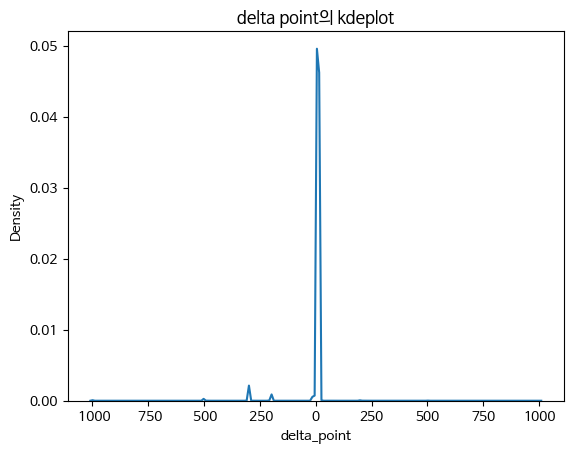

In [300]:
sns.kdeplot(pointhistory_df['delta_point'])
plt.title('delta point의 kdeplot')
plt.show()

/home/sprintda07/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


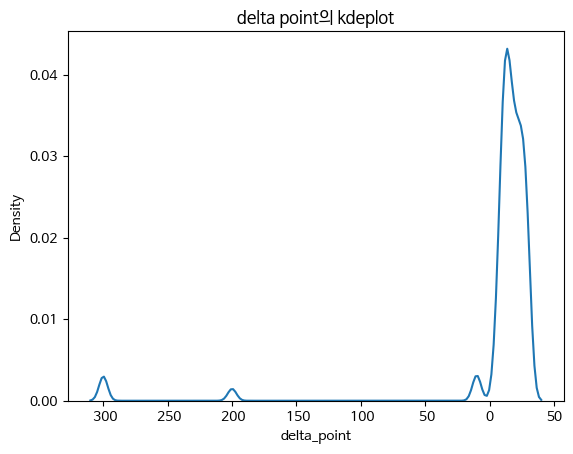

In [165]:
sns.kdeplot(vote_point_df['delta_point'])
plt.title('delta point의 kdeplot')
plt.show()

In [166]:
vote_point_df[vote_point_df['delta_point'] >= 0]

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,created_at_point,user_question_record_id,id_point,delta_point,user_id_point,time_diff
1486,2146629,C,2023-05-02 11:41:13,849436,183,850574,2645618,0,N,2023-05-02 11:41:13,0,0,2023-05-02 11:41:14,2146629.0,2210454.0,12.0,849436.0,1.0
1492,2153347,C,2023-05-02 11:53:22,850556,444,850031,2748024,0,N,2023-05-02 11:53:22,0,0,2023-05-02 11:53:23,2153347.0,2223180.0,5.0,850556.0,1.0
1500,2157014,C,2023-05-02 11:59:25,849504,288,850215,2715175,0,N,2023-05-02 11:59:25,0,0,2023-05-02 11:59:26,2157014.0,2230658.0,14.0,849504.0,1.0
1501,2157095,C,2023-05-02 11:59:34,850633,453,850215,2715177,1,N,2023-05-02 11:59:34,0,0,2023-05-02 11:59:35,2157095.0,2230824.0,11.0,850633.0,1.0
1504,2161745,C,2023-05-02 12:07:16,855180,295,849692,2746913,0,N,2023-05-02 12:07:16,0,0,2023-05-02 12:07:17,2161745.0,2240307.0,11.0,855180.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217549,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,2024-05-07 11:29:07,161666166.0,340671667.0,16.0,NaN,0.0
1217550,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,2024-05-08 01:34:56,161666461.0,340672368.0,10.0,NaN,0.0
1217551,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,2024-05-08 01:35:02,161666462.0,340672370.0,28.0,NaN,0.0
1217552,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,2024-05-08 01:36:00,161666463.0,340672372.0,22.0,NaN,0.0


In [222]:
vote_point_df.groupby('status')['delta_point'].agg(['count', 'mean'])

,count,mean
status,,
B,658,-18.481763
C,1156318,17.377249
I,60578,-197.712833


In [223]:
vote_point_df.groupby('has_read')['delta_point'].agg(['count', 'mean'])

,count,mean
has_read,,
0,541626,16.067709
1,675928,-0.885112


In [224]:
vote_point_df.groupby('answer_status')['delta_point'].agg(['count', 'mean'])

,count,mean
answer_status,,
A,111761,-8.542112
N,1097928,8.446031
P,7865,-27.214495


In [225]:
vote_point_df.groupby('opened_times')['delta_point'].agg(['count', 'mean'])

,count,mean
opened_times,,
0,1156892,17.375824
1,46882,-201.637110
2,11120,-187.286061
3,2660,-173.595113


In [243]:
vote_point_df.groupby(['opened_times','has_read'])['delta_point'].agg(['count', 'mean'])

count        mean
opened_times has_read                    
0            0         537994   17.828173
             1         618898   16.982608
1            0           3632 -244.702919
             1          43250 -198.020578
2            1          11120 -187.286061
3            1           2660 -173.595113

In [228]:
vote_simple_table = mem_con.execute("""
                            SELECT user_id,	STRFTIME(created_at, '%Y_%m') AS year_month, question_id,	chosen_user_id,	delta_point, has_read, answer_status, report_count, opened_times,
                            FROM vote_point_df
                            """).df()
vote_simple_table.head()

,user_id,year_month,question_id,chosen_user_id,delta_point,has_read,answer_status,report_count,opened_times
0,849452,2023_04,209,849489,-300.0,0,N,0,1
1,849477,2023_04,253,849436,-300.0,0,N,0,1
2,849566,2023_04,117,849479,-300.0,0,N,0,1
3,849558,2023_04,110,849503,-300.0,1,N,0,1
4,850039,2023_04,210,849983,-300.0,0,N,0,1


In [231]:
vote_date = vote_simple_table['year_month'].value_counts().reset_index()
vote_date

,year_month,count
0,2023_05,1104677
1,2023_06,71341
2,2023_04,30798
3,2023_07,5396
4,2023_08,2050
5,2023_09,1665
6,2023_12,502
7,2023_10,330
8,2023_11,253
9,2024_01,236


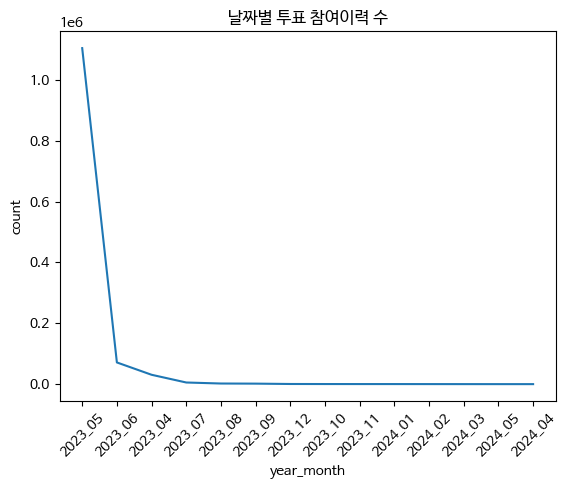

In [266]:
sns.lineplot(data= vote_date, x='year_month', y='count')
plt.xticks(rotation=45)
plt.title("날짜별 투표 참여이력 수")
plt.show()

### 4) 질문내용 확인

In [237]:
vote_question_table = mem_con.execute("""
    SELECT 
        v.user_id,
        STRFTIME(v.created_at, '%Y_%m') AS year_month,
        v.question_id,
        q.question_text,
        v.chosen_user_id,
        v.delta_point,
        v.has_read,
        v.answer_status,
        v.report_count,
        v.opened_times
    FROM vote_point_df AS v
    LEFT JOIN polls_question_df AS q
    ON v.question_id = q.id
""").df()

In [238]:
vote_question_table.head()

,user_id,year_month,question_id,question_text,chosen_user_id,delta_point,has_read,answer_status,report_count,opened_times
0,849452,2023_04,209,항상 좋은 냄새가 나는 사람은?,849489,-300.0,0,N,0,1
1,849477,2023_04,253,생각이 가장 깊은 사람은?,849436,-300.0,0,N,0,1
2,849566,2023_04,117,조용한 매력이 있는 친구,849479,-300.0,0,N,0,1
3,849558,2023_04,110,내가 성별이 바뀐다면 만나고 싶은 사람은?,849503,-300.0,1,N,0,1
4,850039,2023_04,210,친구들에게 가장 인정받는 사람은?,849983,-300.0,0,N,0,1


In [239]:
vote_question_table['question_text'].nunique()

3902

In [270]:
print("상위 10개 질문", vote_question_table['question_text'].value_counts().head(10))
print('-------------------------')
print("하위 10개 질문", vote_question_table['question_text'].value_counts().tail(10))

상위 10개 질문 question_text
vote                             9695
2세가 가장 귀여울 것 같은 사람은?             2171
같이 캠핑가고 싶은 사람은?                  2122
라면 잘 끓일 것 같은 사람은?                2114
처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?    1996
모든 사람과 잘 지낼 것 같은 사람은?            1986
축제에서 공연을 제일 잘 할거 같은 사람은?         1984
앞으로의 인생을 가장 재미있게 살것 같은 사람은?      1974
반려동물과 가장 잘 지낼거 같은 사람은?           1956
가장 깔끔할 것 같은 친구는?                 1956
Name: count, dtype: int64
-------------------------
하위 10개 질문 question_text
MBTI 제일 반전이였던 친구는?                      5
내가 가장 아끼는 친구                            4
한번쯤 목마를 태워주고 싶은사람은?                     4
가장 냉정한 사람                               4
여기서 연락 기다리고 있는 사람은?                     4
떨어져 있어도 같이 있는 것 같은 사람은?                 4
만약에 영혼이 바뀐다면 누가 되고싶어?                   4
사달라는거 다 사줄 것 같은 사람은?                    1
개학 하자마자 인사 될것 같은 사람                     1
할머니,  할아버지가 돼도 이 친구만큼은 연락하고 지낼 것 같아!    1
Name: count, dtype: int64


### 4) 이벤트 테이블

In [271]:
event_info_df.head()

,id_log,created_at_log,event_id,user_id,plus_point_log,id_event,title,plus_point_event,event_type,is_expired,created_at_event
0,2,2023-06-22 09:25:16,1,1193618,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
1,3,2023-06-22 09:38:53,1,928351,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
2,4,2023-06-22 10:32:15,1,904872,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
3,5,2023-06-22 13:03:06,1,974697,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
4,6,2023-06-22 13:40:38,1,1168260,500,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38


In [274]:
event_info_df['user_id'].nunique()

308